In [10]:
import numpy as np
import json

future_forecast = np.load('../data/processed/tsla_future_forecast.npy')

with open('../data/processed/forecast_meta.json') as f:
    forecast_meta = json.load(f)

N_FUTURE = forecast_meta['N_FUTURE']
tsla_last_price = forecast_meta['tsla_last_price']
tsla_forecast_final = forecast_meta['tsla_forecast_final']

print(f"Loaded forecast: {N_FUTURE} days, last price {tsla_last_price:.2f}, "
      f"forecast final {tsla_forecast_final:.2f}")

Loaded forecast: 189 days, last price 411.84, forecast final 265.90


In [2]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pypfopt import EfficientFrontier, risk_models
from pypfopt.expected_returns import mean_historical_return

adj_close = pd.read_csv('../data/processed/adj_close_combined.csv', index_col='Date', parse_dates=True)
returns = adj_close.pct_change().dropna()

In [8]:
adj_close = pd.read_csv(
    "../data/processed/adj_close_combined.csv",
    index_col="Date",
    parse_dates=True,
)

returns = adj_close.pct_change().dropna()

tsla = adj_close["TSLA"]

Build the expected returns vector
TSLA uses LSTM forecast; BND and SPY use historical averages

In [11]:
# TSLA: annualize the LSTM's forecasted return over the forecast horizon
tsla_forecast_total_return = (tsla_forecast_final / tsla_last_price) - 1
tsla_expected_annual_return = (1 + tsla_forecast_total_return) ** (252 / N_FUTURE) - 1

# BND, SPY: historical annualized mean return
bnd_expected = returns['BND'].mean() * 252
spy_expected = returns['SPY'].mean() * 252

expected_returns = pd.Series({
    'TSLA': tsla_expected_annual_return,
    'BND': bnd_expected,
    'SPY': spy_expected
})
print(expected_returns)

TSLA   -0.441986
BND     0.019231
SPY     0.139070
dtype: float64


In [12]:
from pypfopt import risk_models

cov_matrix = risk_models.sample_cov(adj_close, returns_data=False)
print(cov_matrix)

          TSLA       BND       SPY
TSLA  0.315057  0.001739  0.048016
BND   0.001739  0.002721  0.001046
SPY   0.048016  0.001046  0.030037


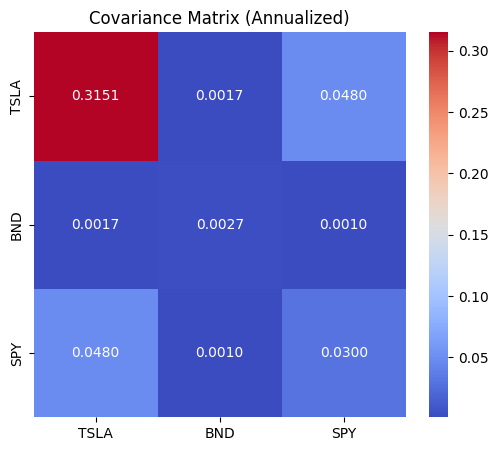

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt='.4f')
plt.title('Covariance Matrix (Annualized)')
plt.savefig('../data/processed/covariance_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

Generate the Efficient Frontier and mark the two key portfolios

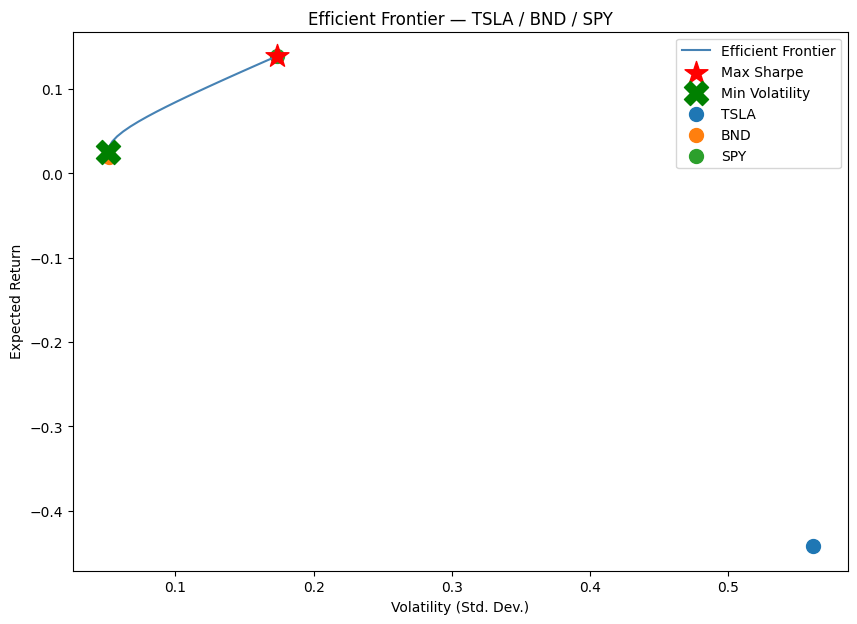

Max Sharpe weights: {'TSLA': 0.0, 'BND': -1e-16, 'SPY': 1.0}
Return: 13.91%, Volatility: 17.33%, Sharpe: 0.687

Min Volatility weights: {'TSLA': 0.0, 'BND': 0.9453990469287102, 'SPY': 0.0546009530712897}
Return: 2.58%, Volatility: 5.13%, Sharpe: 0.113


In [18]:
from pypfopt import EfficientFrontier

# Generate the efficient frontier manually by scanning target returns
n_points = 100
target_returns = np.linspace(expected_returns.min(), expected_returns.max() * 0.99, n_points)

frontier_volatility = []
frontier_returns = []

for target in target_returns:
    try:
        ef = EfficientFrontier(expected_returns, cov_matrix)
        ef.efficient_return(target_return=target)
        ret, vol, _ = ef.portfolio_performance()
        frontier_returns.append(ret)
        frontier_volatility.append(vol)
    except Exception:
        continue  # skip infeasible target returns

# Max Sharpe portfolio
ef_max_sharpe = EfficientFrontier(expected_returns, cov_matrix)
weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=0.02)
ret_ms, vol_ms, sharpe_ms = ef_max_sharpe.portfolio_performance(risk_free_rate=0.02)

# Min volatility portfolio
ef_min_vol = EfficientFrontier(expected_returns, cov_matrix)
weights_min_vol = ef_min_vol.min_volatility()
ret_mv, vol_mv, sharpe_mv = ef_min_vol.portfolio_performance(risk_free_rate=0.02)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(frontier_volatility, frontier_returns, linestyle='-', color='steelblue', label='Efficient Frontier')
ax.scatter(vol_ms, ret_ms, marker='*', s=300, c='red', label='Max Sharpe', zorder=5)
ax.scatter(vol_mv, ret_mv, marker='X', s=300, c='green', label='Min Volatility', zorder=5)

# Plot individual assets too
individual_vols = np.sqrt(np.diag(cov_matrix))
for asset in expected_returns.index:
    ax.scatter(individual_vols[cov_matrix.columns.get_loc(asset)], expected_returns[asset],
               marker='o', s=100, label=asset)

ax.set_xlabel('Volatility (Std. Dev.)')
ax.set_ylabel('Expected Return')
ax.set_title('Efficient Frontier — TSLA / BND / SPY')
ax.legend()
plt.savefig('../data/processed/efficient_frontier.png', dpi=100, bbox_inches='tight')
plt.show()

print("Max Sharpe weights:", dict(weights_max_sharpe))
print(f"Return: {ret_ms:.2%}, Volatility: {vol_ms:.2%}, Sharpe: {sharpe_ms:.3f}")
print()
print("Min Volatility weights:", dict(weights_min_vol))
print(f"Return: {ret_mv:.2%}, Volatility: {vol_mv:.2%}, Sharpe: {sharpe_mv:.3f}")

## Portfolio Recommendation

Given the LSTM's forecast of a declining TSLA price over the next 9 months 
(expected annualized return of -44.2%), the optimizer allocates 0% to TSLA 
in both candidate portfolios — a direct and logical consequence of Modern 
Portfolio Theory, which will not allocate capital to an asset with a 
negative expected return regardless of its diversification properties.

**Maximum Sharpe Ratio Portfolio:** 100% SPY, 0% TSLA, 0% BND
- Expected annual return: 13.91%
- Expected annual volatility: 17.33%
- Sharpe Ratio: 0.687

**Minimum Volatility Portfolio:** 94.5% BND, 5.5% SPY, 0% TSLA
- Expected annual return: 2.58%
- Expected annual volatility: 5.13%
- Sharpe Ratio: 0.113

**Recommendation:** The Maximum Sharpe Ratio portfolio is recommended for 
clients seeking the best risk-adjusted return, as it delivers nearly 3x the 
volatility-adjusted performance of the Minimum Volatility portfolio (Sharpe 
0.687 vs. 0.113). For more conservative clients prioritizing capital 
preservation, the Minimum Volatility portfolio remains a reasonable 
alternative, trading most upside for a substantially lower-risk, bond-heavy 
allocation.

It is important to note that this recommendation is conditional on the 
LSTM's specific 9-month forecast. TSLA's exclusion here reflects one model's 
point-in-time view, not a permanent judgment on the asset — a materially 
different forecast (from a different model, training run, or updated data) 
could shift TSLA back into the optimal allocation. This dependency is a 
limitation worth flagging explicitly to GMF's investment committee: the 
portfolio recommendation is only as reliable as the underlying return 
forecast that feeds it, consistent with the EMH-driven caution discussed 
in Section 2.

In [19]:
import json

portfolio_output = {
    'weights_max_sharpe': dict(weights_max_sharpe),
    'weights_min_vol': dict(weights_min_vol),
    'max_sharpe_performance': {'return': ret_ms, 'volatility': vol_ms, 'sharpe': sharpe_ms},
    'min_vol_performance': {'return': ret_mv, 'volatility': vol_mv, 'sharpe': sharpe_mv},
}
with open('../data/processed/portfolio_weights.json', 'w') as f:
    json.dump(portfolio_output, f)

print("Saved portfolio weights for Task 5.")

Saved portfolio weights for Task 5.
